In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import math as mt

# 1. Cash or CStat statistic

Let the expected number of signal counts be $n_s$, and given $n_{bkg}$, we have, using the fact that the distribution of the sum of two Poissonian RVs is a Possion with their means summed, the following likelihood for observing $n_{on}$ counts:
$$
L = \frac{(n_s+n_{bkg})^{n_{on}}e^{-(n_s+n_{bkg})}}{n_{on}!}
$$
Defining $l=-\ln L$, we have:
$$
l = n_{s} - n_{on}\ln (n_s+n_{bkg}) + \kappa
$$
where $\kappa$ denotes that the rest of the expression is a constant in terms of $n_{s}$. This has been done because while obtaining our MLE, we need to minimize $l$, and hence upon carrying out a partial differentiation wrt $n_{s}$, the term $\kappa$ would drop.
Thus, denoting our MLE for $n_{s}$ as $\hat{n}_s$, we have:

\begin{align}
&\left(\frac{\partial l}{\partial n_{s}}\right)_{n_s = \hat{n}_s} = 0 \nonumber\\
\implies& 1 - \frac{n_{on}}{\hat{n}_s+n_{bkg}} = 0 \nonumber\\
\implies& \hat{n}_s = n_{on}-n_{bkg}\\
\end{align}

Given $n_{on} = 10$, and $n_{bkg} = 3$, we have $\hat{n}_s = 7$, as our excess.

Taking the null hypothesis to be $n_s = 0$, we have the log-ratio statistic for our case as:
$$
\mu = 2 \left( l(n_s = 0) - l(n_s)\right)
$$
upon caarying out the subtraction in the above equation, $\kappa$ drops out, and we have:
\begin{align}
\mu &= 2\left(-n_{on}\ln (n_{bkg}) - \left(n_{s} - n_{on}\ln (n_s+n_{bkg})\right)\right) \nonumber\\
\mu & = -2\left(n_s+n_{on}\ln\left(\frac{n_{bkg}}{n_{s}+n_{bkg}}\right)\right)
\end{align}
For the observed data, $n_{on} = 10$, and given $n_{bkg} = 3$, using $\hat{n}_s = 7$, we have $\mu_0 = \mu(n_s = \hat{n}_s)$ as the value that our test statistic takes. Now, as per Wilks' theorem, $\mu_0$ is a random variable which follows the $\chi^2$ distribution with D.O.F. 1 upon repeated experiments, given that the null hypothesis (i.e., no signal) is true. For the given observation, we have the significance of detection given by:
$$
S = \Phi^{-1}(1-p)
$$
where
$$
p = \int_{\mu_0}^{\infty}f(\chi_1^2)d\chi^2
$$
This calculation is carried out in the code block below:

In [28]:
mu_0 = -2.0*(7.0+10.0*(np.log((3.0)/(10.0)))) ## test-statistic varying as chi^2 with dof = 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_0, df=1) ## p-value for the observed test statistic
p_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_one_sided) ## siginificance from p-value
print(f"Detection significance: {detection_sig:.2f} $\\sigma$")

Detection significance: 3.17 $\sigma$


Thus, the significance of detection is $S = 3.17\sigma$.

The $a\sigma$ confidence interval is given by $|\mu(n_s)-\mu(\hat{n}_s)|\le a^2$. The following code block finds the C.I. for $a=1,2$, and also plots the likelihood profile.

1 sigma confidence interval for \hat{n}_s: [4.16, 10.49]
2 sigma confidence interval for \hat{n}_s: [1.94, 14.71]


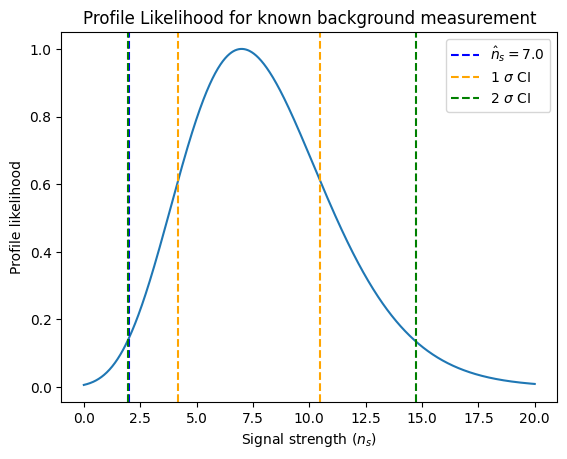

In [52]:
n_s_vals = np.linspace(0,20,1000)
n_bkg = 3.0
n_on = 10.0
def nll(n_on, n_s, n_bkg = 3.0):
    nll_val = n_s - n_on*np.log(n_s + n_bkg)
    return nll_val
mu_n_s = 2.0*(nll(n_on, n_s_vals, n_bkg) - nll(n_on, 7.0, n_bkg))
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for known background measurement")

## 1 sigma CI
ci_1sigma = n_s_vals[mu_n_s <= 1.0]
print(f"1 sigma confidence interval for \\hat{{n}}_s: [{ci_1sigma[0]:.2f}, {ci_1sigma[-1]:.2f}]")

## 2 sigma CI
ci_2sigma = n_s_vals[mu_n_s <= 4.0]
print(f"2 sigma confidence interval for \\hat{{n}}_s: [{ci_2sigma[0]:.2f}, {ci_2sigma[-1]:.2f}]")

## ploting 1 sigma and 2 sigma and the best fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s = 7.0$')
plt.axvline(ci_1sigma[0], color='orange', linestyle='--', label='1 $\\sigma$ CI')
plt.axvline(ci_1sigma[-1], color='orange', linestyle='--')
plt.axvline(ci_2sigma[0], color='green', linestyle='--', label='2 $\\sigma$ CI')
plt.axvline(ci_2sigma[-1], color='green', linestyle='--')
plt.legend()
plt.show()

The $1\sigma$ C.I. for the excess is [4.16, 10.49]. The $2\sigma$ C.I. for the excess is [1.94, 14.71].

Now, for the case of $n_{on} = 5$, $n_{bkg}= 3$, the excess is $\hat{n}_s = 5 - 3 = 2$. The test statistic for this case becomes $\mu_0 = -2\left(2+5\ln\left(\frac{3}{5}\right)\right)$. It's significance is calculated in the code block below:

In [51]:
n_s_hat = 2.0
n_on = 5.0
n_bkg = 3.0
mu_0 = 2.0*(nll(n_on, 0.0, n_bkg) - nll(n_on, n_s_hat, n_bkg)) ## test-statistic varying as chi^2 with dof = 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_0, df=1) ## p-value for the observed test statistic
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for n_s = 2: {detection_sig:.2f} $\\sigma$")

Detection significance for n_s = 2: 1.05 $\sigma$


The significance of detection for this case is $1.05\sigma$. The code block plots the likelihood profile, and the $5\sigma$ upper limit on the excess.

5 sigma upper limit for \hat{n}_s: 22.67


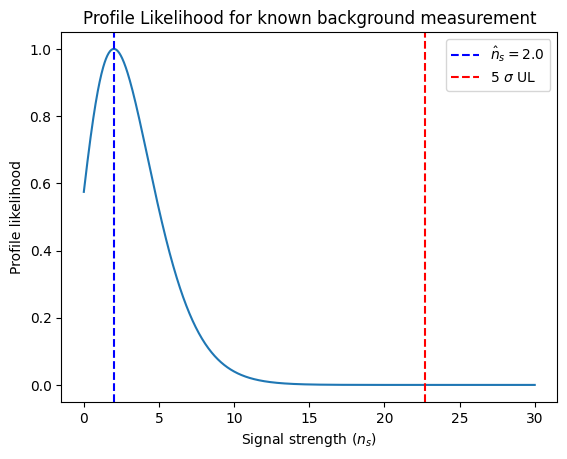

In [46]:
n_s_vals = np.linspace(0,30,1000)
n_bkg = 3.0
n_on = 5.0
n_s_hat = 2.0
def nll(n_on, n_s, n_bkg = 3.0):
    nll_val = n_s - n_on*np.log(n_s + n_bkg)
    return nll_val
mu_n_s = 2.0*(nll(n_on, n_s_vals, n_bkg) - nll(n_on, n_s_hat, n_bkg))
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for known background measurement")

## 5 sigma upper limit
ci_5sigma = n_s_vals[mu_n_s <= 25.0]
print(f"5 sigma upper limit for \\hat{{n}}_s: {ci_5sigma[-1]:.2f}")

## ploting 5 sigma UL and the best fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s = 2.0$')
plt.axvline(ci_5sigma[-1], color='red', linestyle='--', label='5 $\\sigma$ UL')
plt.legend()
plt.show()

The $5\sigma$ upper limit on the excess is 22.67.

# 2. WStat Statistic

Here, the expected background during measurements in $t_{on}$ is not known. Now, for a measurement of $t_{off}$, and $t_{on}$ durations, take $N_{off}$, and $N_{on}$ as the respective observed counts. Let $n_{b,~on}$ be the expected background when the detector is recording for a time $t_{on}$. As off-time measurements only contain the background, we have that $N_{off}$ varies as a Poisson random variable with mean say $n_{off}$. Now, assuming a constant bacgkround rate of $r_b = \frac{n_{off}}{t_{off}}$, during both the source off and source on measurements, we have $n_{b,~on} = t_{on}\frac{n_{off}}{t_{off}} = \alpha n_{off}$.

So, the likelihood of observing the data would be:
$$
L = \frac{n_{on}^{N_{on}}e^{-n_{on}}}{N_{on}!} \frac{n_{off}^{N_{off}}e^{-n_{off}}} {N_{off}!}
$$
where $n_{on}$ is the expected source on-time measurement, and the factor corresponding to off-time measurement comes in due to it being an independent one form the on-time measurement. Since we model the counts in the on region being due to both the signal and the background, we would have the expected value of counts during $t_{on}$ to be $n_{on} = n_{s}+n_{b,on}$, where $n_{s}$ is the expected counts due to the source. This was possible because the sum of two Poissonian random variables being a Possion random variable with the mean the same as the sum of their individual means. So, we have:
$$
L = \frac{(n_{s}+\alpha n_{off})^{N_{on}}e^{-(n_{s}+\alpha n_{off})}}{N_{on}!}\frac{n_{off}^{N_{off}}e^{-n_{off}}} {N_{off}!}
$$
Defining the negative log likelihood as in the first question:
$$
l = -\ln L = n_{s}+ \alpha n_{off} - N_{on}\ln(n_{s}+\alpha n_{off}) + n_{off} - N_{off}\ln n_{off} + C
$$
where $C$ is a constant independent of the parameters to be fixed by MLE, and thus, won't affect the minimization of $l$.

Now, the MLE for $n_{s}$ is:

\begin{align}
&\left(\frac{\partial l}{\partial n_s}\right)_{\hat{n}_{s}} = 0 \nonumber\\
\implies&~-\frac{N_{on}}{\hat{n}_{s}+\alpha n_{off}}+1 = 0
\end{align}
For $n_{off}$ we have:
\begin{align}
&\left(\frac{\partial l}{\partial n_{off}}\right)_{\hat{n}_{off}} = 0 \nonumber\\
\implies&~-\alpha\frac{N_{on}}{\hat{n}_{s}+\alpha n_{off}}+\alpha - \frac{N_{off}}{n_{off}} + 1 = 0 \nonumber \\
\implies&~\alpha\left[-\frac{N_{on}}{\hat{n}_{s}+\alpha n_{off}}+1\right] - \frac{N_{off}}{n_{off}} + 1 = 0 \nonumber
\end{align}
The first term on the LHS of the above equation is 0 from Eq. (1). So, we have, the MLE of $\hat{n}_{off}$ that minimizes $l$ at the gloabl maximum likelihood, as:
$$
\hat{n}_{off} = N_{off}
$$
So, we then have, with this value of $n_{off}$:
$$
\hat{n}_s + \alpha N_{off} = N_{on} \implies \hat{n}_{s} = N_{on} - \alpha N_{off}
$$
This is our MLE for $n_{s}$, and $n_{off}$.

Now, we have our test statistic for the background only hypothesis given by 
$$
\mu = 2 \left(l(n_s = 0,~\hat{n}_{off}|_{n_s = 0}) - l(n_s = N_{on} - \alpha N_{off}, n_{off} = \hat{n}_{off}|_{n_s})\right)
$$
and we have by Wilk's theorem that $\mu\sim\chi_{1}^2$.
The second term in the above equation is the global MLE of $n_s$ and $n_{off}$. The first term is obtained from the MLE of $n_{off}$ when $n_s$ is fixed at 0.
When $n_s = 0$, we have:
$$
\alpha\left[-\frac{N_{on}}{\alpha n_{off}}+1\right] - \frac{N_{off}}{n_{off}} + 1 = 0 \\
\implies \alpha + 1 = \frac{N_{on}+N_{off}}{n_{off}}\\
\implies n_{off} = \frac{N_{on}+N_{off}}{\alpha + 1}
$$
Now, $\mu$ can be calculated by defining the negative log-likelihood function with $n_s$ and $n_{off}$ as inputs. For a complicated enough scenario we would need to minimize the negative log-likelihood using minuit or other minimization packages. It is not needed here for obtaining signal significance, as the derivations of minima have been analytic. I carry out both to see consistency in he result.

In [10]:
def nll_on_off(N_on, N_off, alpha, n_off, n_s = 0):
    """
    Inputs -->
    N_on [integer] : Observed counts with source on
    N_off [integer] : Observed counts with source off
    alpha [float] : Acceptance
    n_off [float] : Expected counts with source off
    n_s [float] : Expected counts with source on -- default value set to 0 for use in background only hypothesis
    Outputs -->
    nll_val [float] : Negative log likelihood value with the given observations modulo constants independent of expected values of n_s and and n_off
    """
    nll_val = 0
    nll_val += n_s + alpha * n_off - N_on * (mt.log(n_s + alpha * n_off))
    nll_val += n_off - N_off * mt.log(n_off)
    return nll_val

## Analytic way
### Calculation for background only hypothesis
N_on = 10.0
N_off = 6.0
alpha = 0.5
n_off_bkg_only = (N_on + N_off)/(alpha + 1.0)
nll_bkg_only = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = n_off_bkg_only, n_s = 0)
### Calculation for global minimum
n_s_global = N_on - alpha * N_off
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = N_off, n_s = n_s_global)
mu_A = 2 * (nll_bkg_only - nll_global)
## mu_A should be a sample from chi^2 with D.O.F. of 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_A, df=1) ## p-value for mu_A
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for N_on = {N_on} in the analytic way: {detection_sig:.2f} $\\sigma$")

## Using Minuit -- just for consistency check, rest of analysis will be done with previous method
### Global minimum
from iminuit import Minuit
#### Building function that focues only on the parameters to maximize likelihood over
def nll_on_off_params_only(n_s, n_off):
    return nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = n_off, n_s = n_s)
#### Starting with initial guesses same as the analytic ones for quicker convergence
m_global = Minuit(
    nll_on_off_params_only,
    n_s   = n_s_global, ## recycling value defined earlier in code
    n_off = N_off,
)
#### Setting limits on n_s, given alpha can at most be 1
#### Setting limits on n_off given we already know we are finding the value for global minimum
m_global.limits["n_s"]   = (N_on - N_off, N_on + N_off)
m_global.limits["n_off"] = (N_off - 2, N_off + 2)
m_global.migrad()
### Background only
m_bkg = Minuit(
    nll_on_off_params_only,
    n_s   = 0,
    n_off = n_off_bkg_only, ## recycling from earlier definition in code
)
m_bkg.values["n_s"] = 0.0
m_bkg.fixed["n_s"]  = True
m_bkg.limits["n_off"] = (n_off_bkg_only - 1, n_off_bkg_only + 1) ## using known range for faster convergence
m_bkg.migrad()
### test statistic using minuit values
nll_bkg_only = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_bkg.values['n_off'], n_s = 0)
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_global.values['n_off'], n_s = m_global.values['n_s'])
mu_M = 2 * (nll_bkg_only - nll_global)
## mu_M should be a sample from chi^2 with D.O.F. of 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_A, df=1) ## p-value for mu_A
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for N_on = {N_on} using Minuit minimization: {detection_sig:.2f} $\\sigma$")

Detection significance for N_on = 10.0 in the analytic way: 2.38 $\sigma$
Detection significance for N_on = 10.0 using Minuit minimization: 2.38 $\sigma$


There is complete agreement between the detection significance using both methods. To procedd further, consider an aribtrary $n_{s}$. The lilelihood maximizing value of $n_{off}$ at that $n_s$ then becomes:
$$
\alpha + 1 = \frac{\alpha N_{on}}{n_{s} + \alpha n_{off}} + \frac{N_{off}}{n_{off}}\\
\therefore (\alpha^2+\alpha) n_{off}^2 + \left((\alpha+1)n_s - \alpha(N_{on} + N_{off})\right)n_{off} - n_s N_{off} = 0
$$
finding the roots of this equation is complex. From here I will use Minuit to obtain the MLE of $n_{off}$ for different given $n_s$.

1 sigma confidence interval for \hat{n}_s: [3.87, 10.66]
2 sigma confidence interval for \hat{n}_s: [1.05, 14.98]


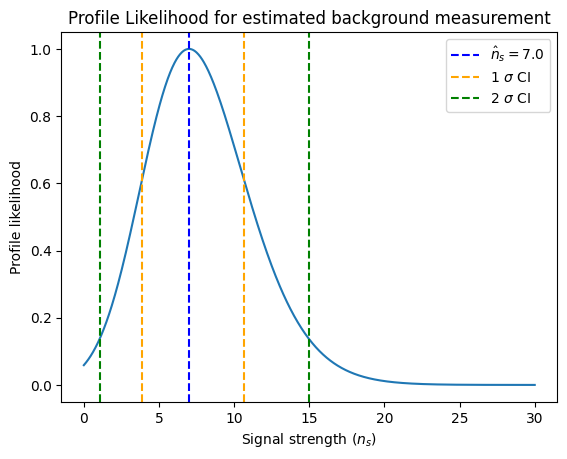

In [16]:
# Characterizing confidence intervals
N_on = 10.0
N_off = 6.0
alpha = 0.5
n_s_global = N_on - alpha * N_off
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = N_off, n_s = n_s_global)
## profiling
n_s_vals = np.linspace(0.0, 30.0, 1000)
nll_at_ns = np.zeros(1000)
## defining root finding for finding likelihood maximizing value of n_off for an arbitrary n_off
for k in range(1000):
    m_ns = Minuit(
    nll_on_off_params_only,
    n_s   = 0,
    n_off = n_off_bkg_only, ## recycling from earlier definition in code
    )
    m_ns.values["n_s"] = n_s_vals[k]
    m_ns.fixed["n_s"]  = True
    m_ns.limits["n_off"] = (1e-6, None) ## using arbitrary range
    m_ns.migrad()
    nll_at_ns[k] = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_ns.values['n_off'], n_s = n_s_vals[k])

## test staitistic
mu_n_s = 2.0*(nll_at_ns - nll_global)
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for estimated background measurement")

## 1 sigma CI
ci_1sigma = n_s_vals[mu_n_s <= 1.0]
print(f"1 sigma confidence interval for \\hat{{n}}_s: [{ci_1sigma[0]:.2f}, {ci_1sigma[-1]:.2f}]")

## 2 sigma CI
ci_2sigma = n_s_vals[mu_n_s <= 4.0]
print(f"2 sigma confidence interval for \\hat{{n}}_s: [{ci_2sigma[0]:.2f}, {ci_2sigma[-1]:.2f}]")

## ploting 1 sigma and 2 sigma and the best fit
plt.axvline(n_s_global, color='blue', linestyle='--', label=f'$\\hat n_s = {n_s_global}$')
plt.axvline(ci_1sigma[0], color='orange', linestyle='--', label='1 $\\sigma$ CI')
plt.axvline(ci_1sigma[-1], color='orange', linestyle='--')
plt.axvline(ci_2sigma[0], color='green', linestyle='--', label='2 $\\sigma$ CI')
plt.axvline(ci_2sigma[-1], color='green', linestyle='--')
plt.legend()
plt.show()
